In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 加载数据
data = pd.read_csv('students03.csv')

# 查看数据结构
print(data.head())

# 删除不必要的列
columns_to_drop = ['身份证']
data_cleaned = data.drop(columns=columns_to_drop)

# 将抑郁症列转换为数值类型（0: 无抑郁症，1: 有抑郁症）
data_cleaned['抑郁症'] = data_cleaned['抑郁症'].astype(int)

# 检查并处理缺失值
data_cleaned = data_cleaned.dropna()

# 查看清洗后的数据结构
print(data_cleaned.head())

   身份证      性别    年龄             城市       职业  学业压力  累积平均绩点  学习满意度  \
0    2    Male  33.0  Visakhapatnam  Student   5.0    8.97    2.0   
1    8  Female  24.0      Bangalore  Student   2.0    5.90    5.0   
2   26    Male  31.0       Srinagar  Student   3.0    7.03    5.0   
3   30  Female  28.0       Varanasi  Student   3.0    5.59    2.0   
4   32  Female  25.0         Jaipur  Student   4.0    8.13    3.0   

                  睡眠时长      饮食习惯       学位 是否有过自杀念头  工作/学习时间  财务压力 精神疾病家族史  抑郁症  
0          '5-6 hours'   Healthy  B.Pharm      Yes      3.0   1.0      No    1  
1          '5-6 hours'  Moderate      BSc       No      3.0   2.0     Yes    0  
2  'Less than 5 hours'   Healthy       BA       No      9.0   1.0     Yes    0  
3          '7-8 hours'  Moderate      BCA      Yes      4.0   5.0     Yes    1  
4          '5-6 hours'  Moderate   M.Tech      Yes      1.0   1.0      No    0  
       性别    年龄             城市       职业  学业压力  累积平均绩点  学习满意度  \
0    Male  33.0  Visakhapatnam  Stu

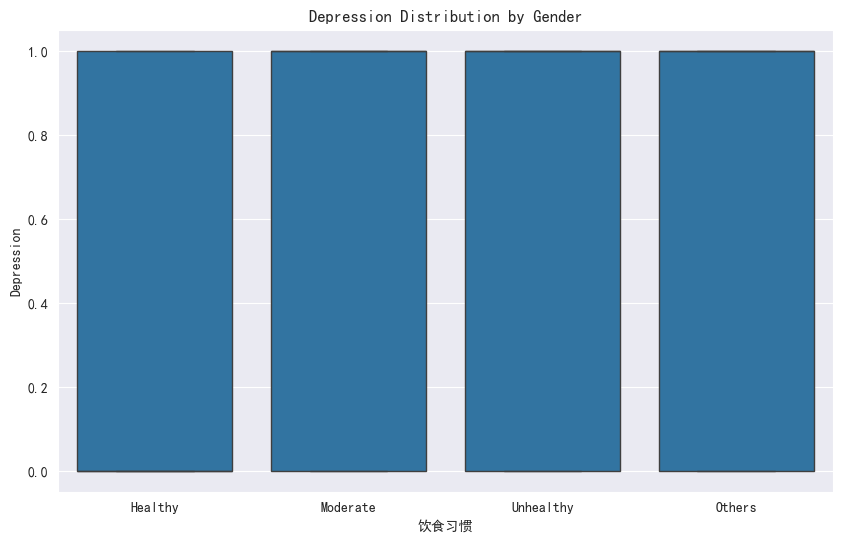

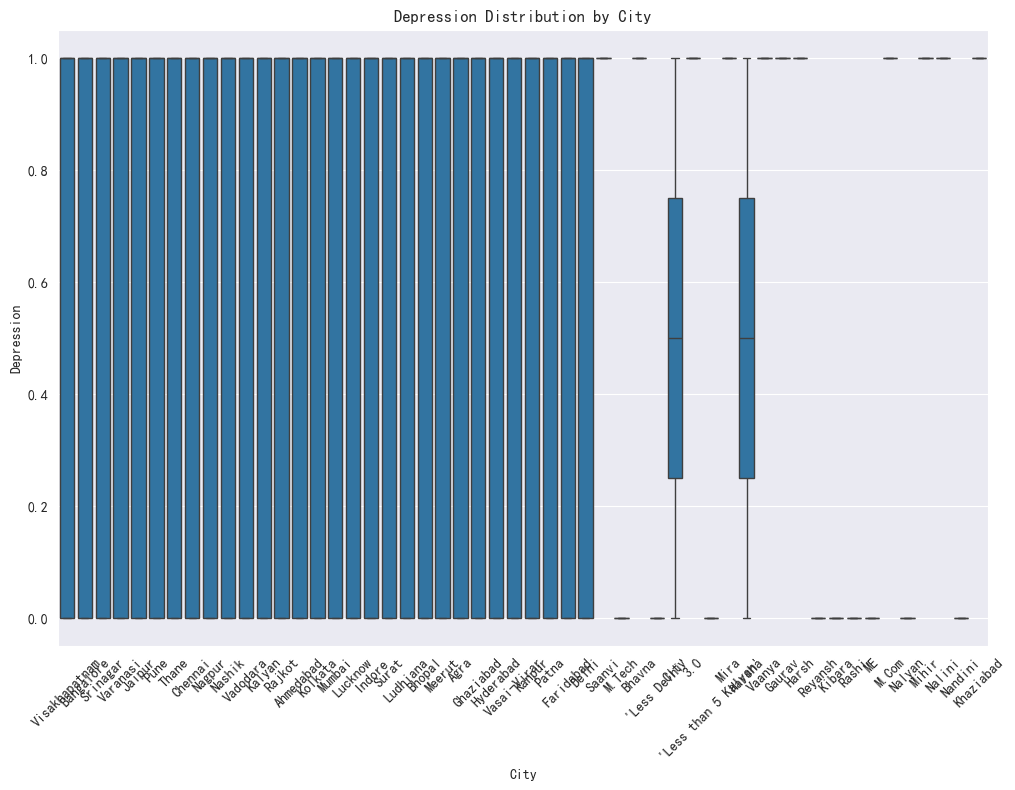

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='饮食习惯', y='抑郁症', data=data_cleaned)
plt.title('Depression Distribution by Gender')
plt.xlabel('饮食习惯')
plt.ylabel('Depression')
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x='城市', y='抑郁症', data=data_cleaned)
plt.title('Depression Distribution by City')
plt.xlabel('City')
plt.ylabel('Depression')
plt.xticks(rotation=45)
plt.show()



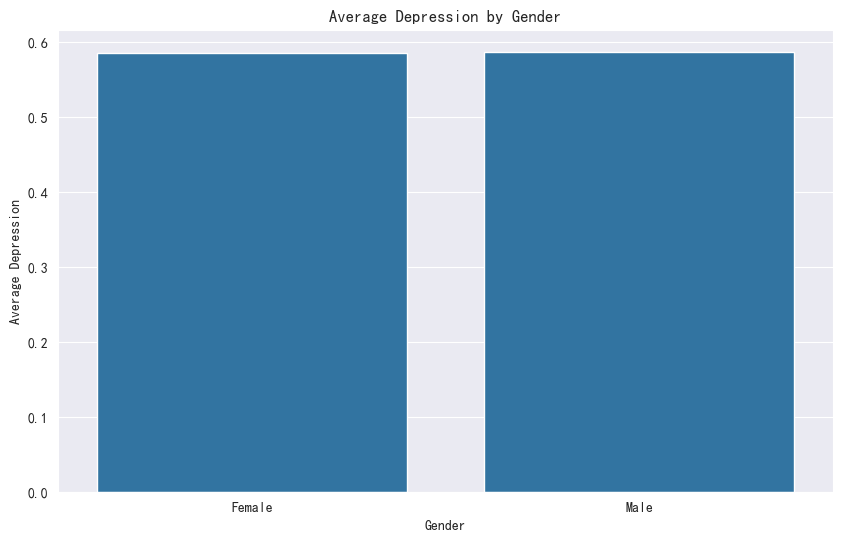

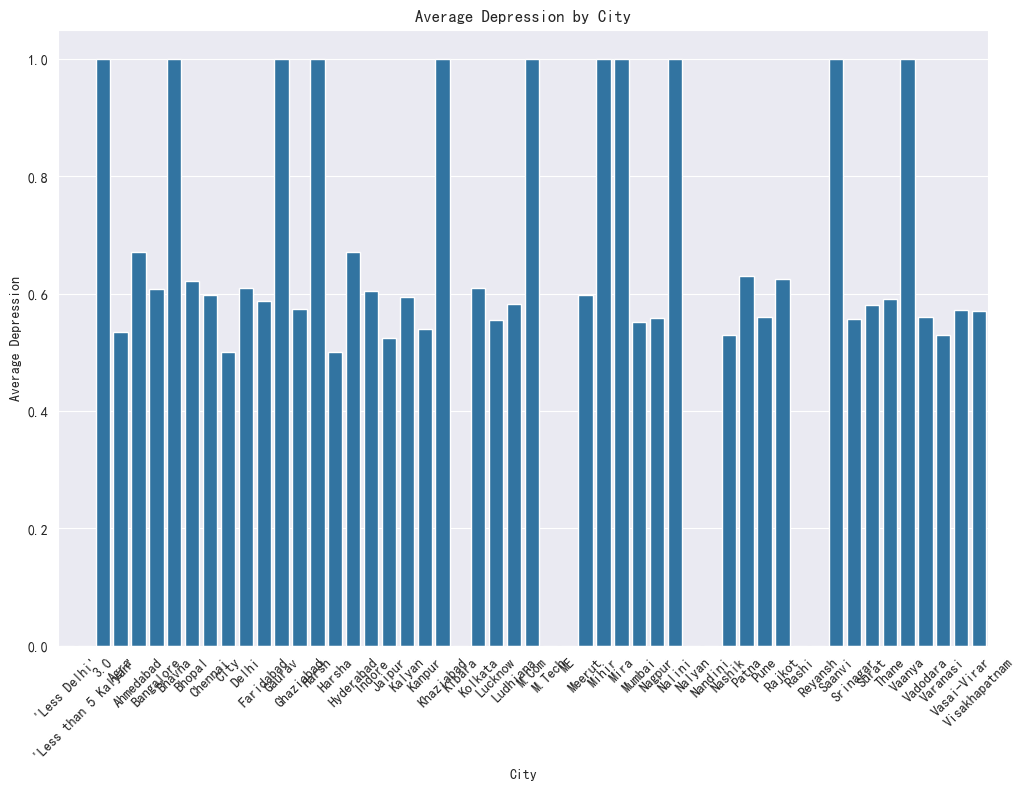

In [24]:
depression_by_gender = data_cleaned.groupby('性别')['抑郁症'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='性别', y='抑郁症', data=depression_by_gender)
plt.title('Average Depression by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Depression')
plt.show()


depression_by_city = data_cleaned.groupby('城市')['抑郁症'].mean().reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(x='城市', y='抑郁症', data=depression_by_city)
plt.title('Average Depression by City')
plt.xlabel('City')
plt.ylabel('Average Depression')
plt.xticks(rotation=45)
plt.show()

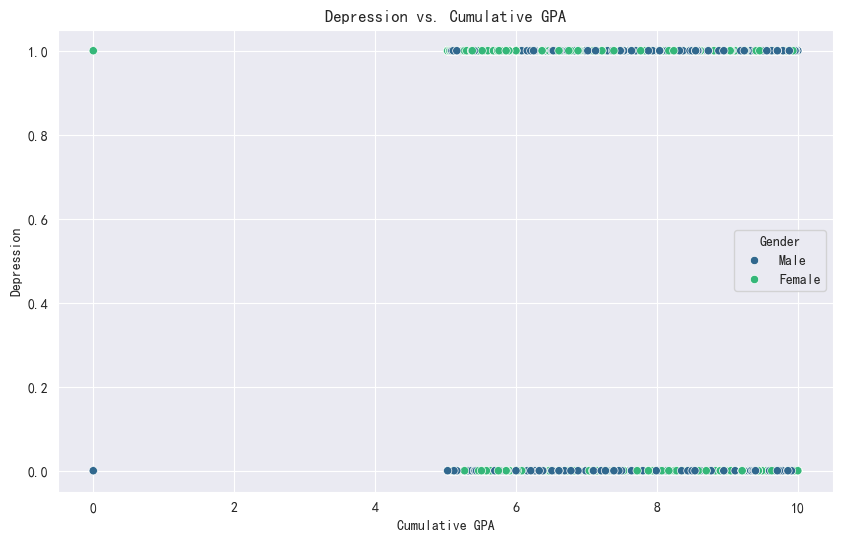

In [15]:
#
plt.figure(figsize=(10, 6))
sns.scatterplot(x='累积平均绩点', y='抑郁症', hue='性别', data=data_cleaned, palette='viridis')
plt.title('Depression vs. Cumulative GPA')
plt.xlabel('Cumulative GPA')
plt.ylabel('Depression')
plt.legend(title='Gender')
plt.show()

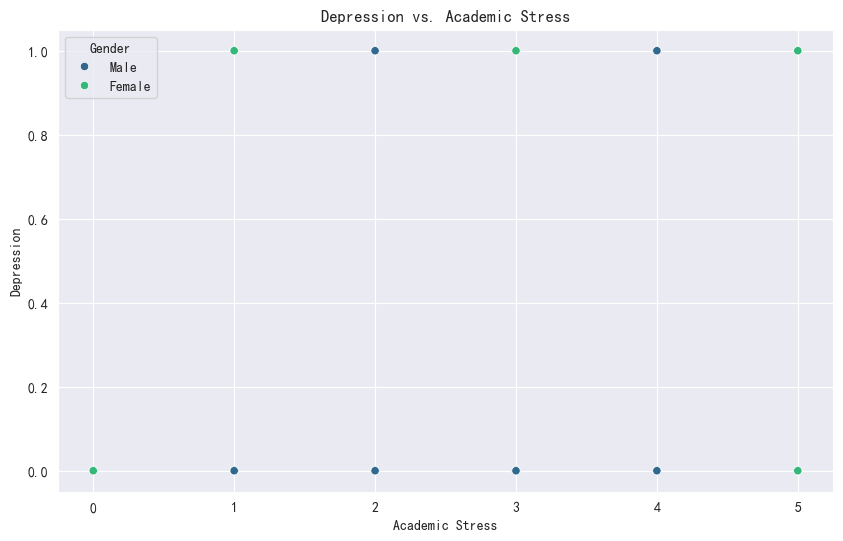

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='学业压力', y='抑郁症', hue='性别', data=data_cleaned, palette='viridis')
plt.title('Depression vs. Academic Stress')
plt.xlabel('Academic Stress')
plt.ylabel('Depression')
plt.legend(title='Gender')
plt.show()

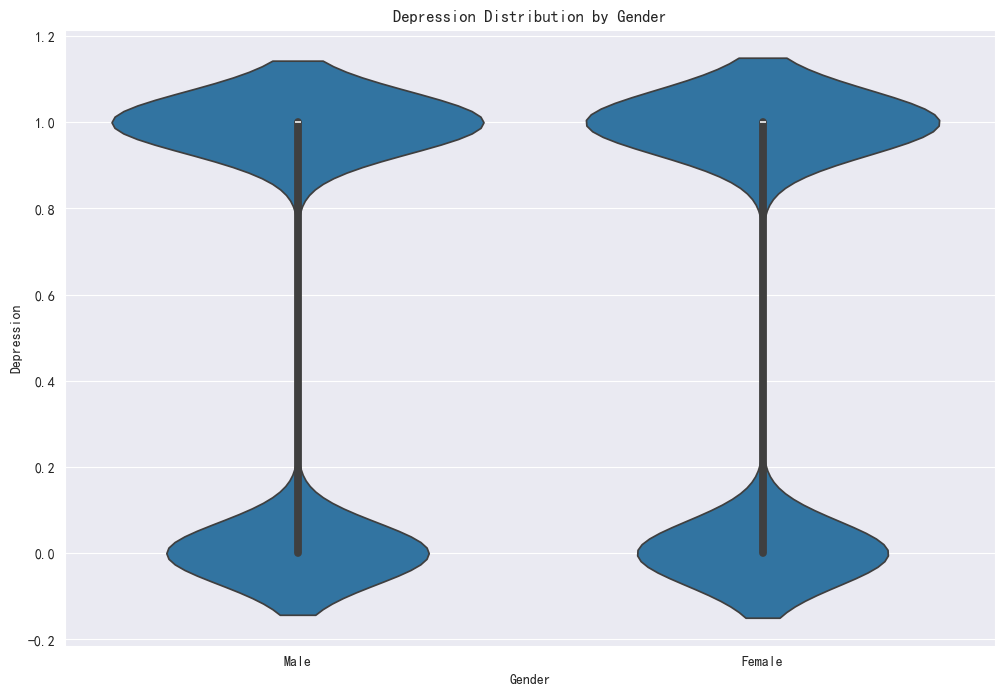

In [17]:
plt.figure(figsize=(12, 8))
sns.violinplot(x='性别', y='抑郁症', data=data_cleaned)
plt.title('Depression Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Depression')
plt.show()

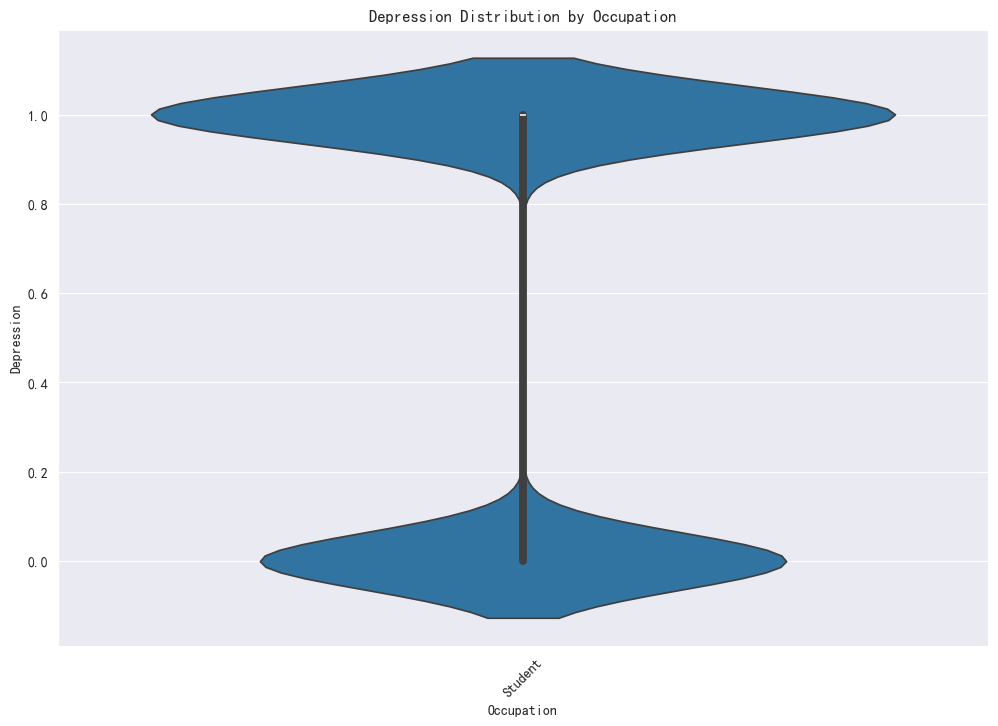

In [18]:
plt.figure(figsize=(12, 8))
sns.violinplot(x='职业', y='抑郁症', data=data_cleaned)
plt.title('Depression Distribution by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Depression')
plt.xticks(rotation=45)
plt.show()

In [19]:
# 计算相关性矩阵
correlation_matrix = data_cleaned.corr()

# 绘制热力图
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'Male'

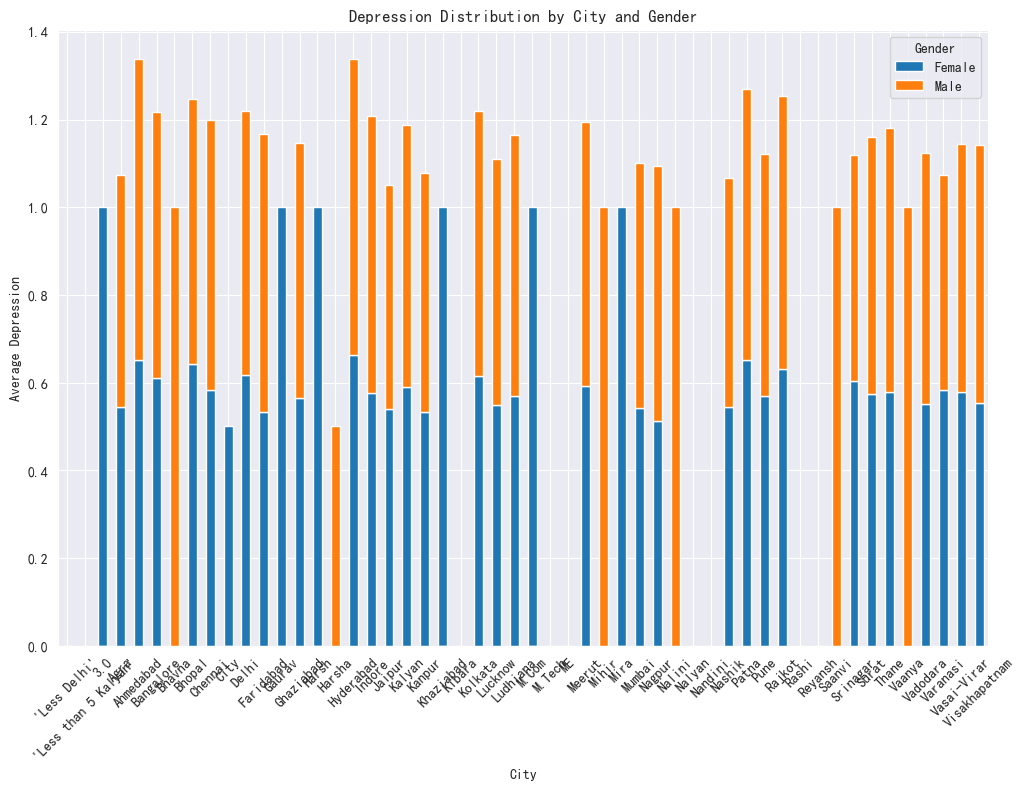

In [20]:
# 以城市和性别为例
city_gender_depression = data_cleaned.groupby(['城市', '性别'])['抑郁症'].mean().unstack().fillna(0)
city_gender_depression.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Depression Distribution by City and Gender')
plt.xlabel('City')
plt.ylabel('Average Depression')
plt.legend(title='Gender')
plt.xticks(rotation=45)
plt.show()

In [21]:
import numpy as np
from math import pi

# 选择要比较的变量
variables = ['学业压力', '累积平均绩点', '睡眠时长', '财务压力']
data_pivot = data_cleaned.pivot_table(index='城市', values=variables, aggfunc='mean').reset_index()

# 创建雷达图
categories = variables + variables[:1]
N = len(categories)

# 计算角度
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# 绘制雷达图
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for index, row in data_pivot.iterrows():
    values = row[variables].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['城市'])
    ax.fill(angles, values, alpha=0.4)

# 添加变量标签
ax.set_thetagrids([a * 180 / pi for a in angles[:-1]], categories)

# 添加图例
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title('Student Performance by City')
plt.show()

TypeError: agg function failed [how->mean,dtype->object]

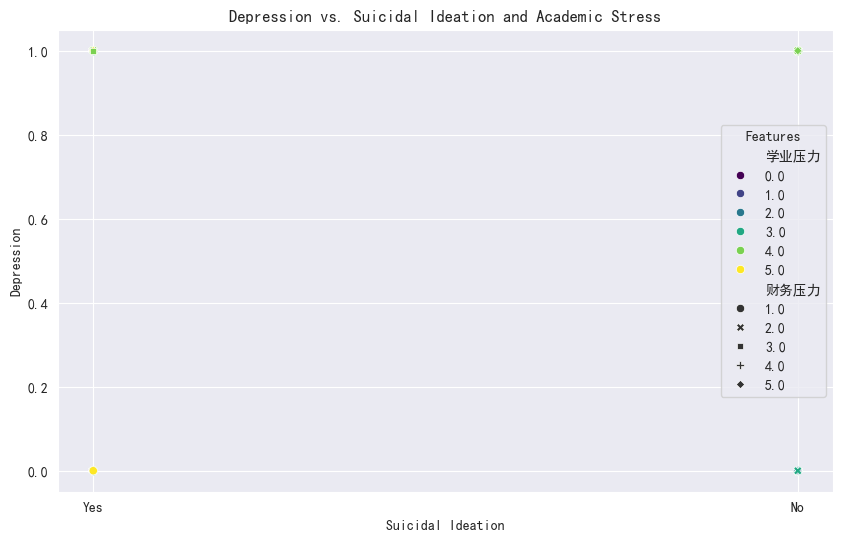

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='是否有过自杀念头', y='抑郁症', hue='学业压力', style='财务压力', data=data_cleaned, palette='viridis')
plt.title('Depression vs. Suicidal Ideation and Academic Stress')
plt.xlabel('Suicidal Ideation')
plt.ylabel('Depression')
plt.legend(title='Features')
plt.show()

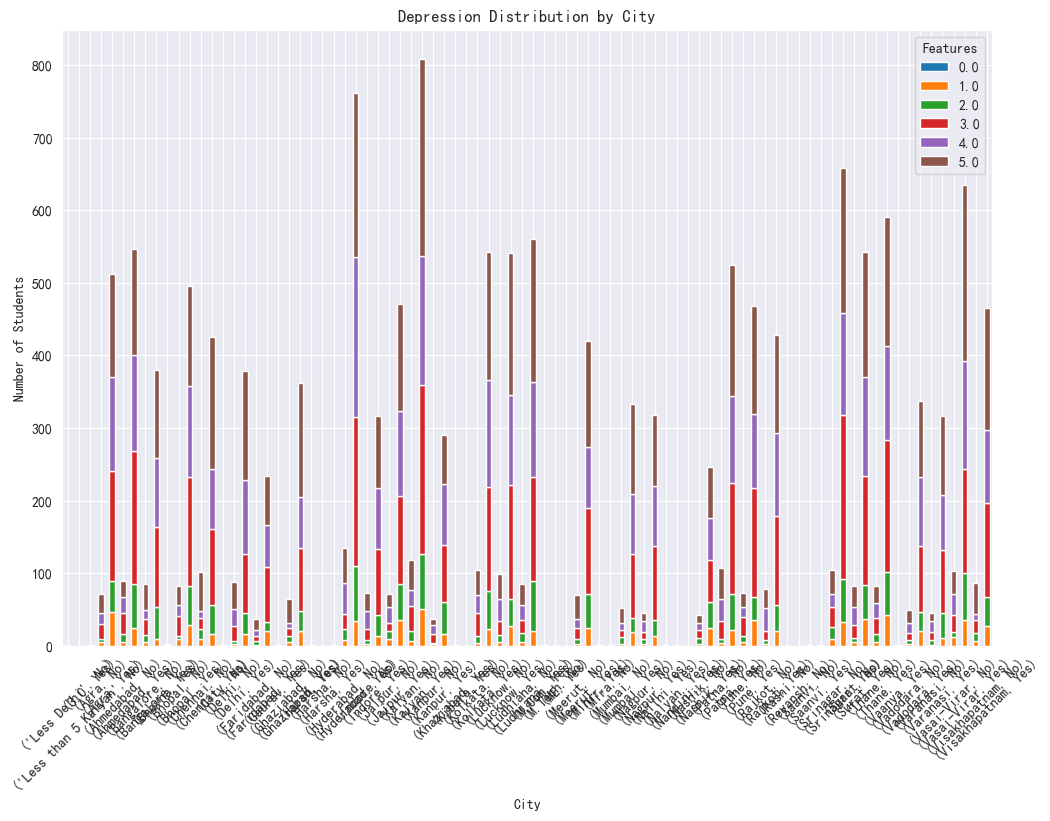

In [26]:
city_depression = data_cleaned.groupby(['城市', '是否有过自杀念头', '学业压力'])['抑郁症'].sum().unstack().fillna(0)
city_depression.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Depression Distribution by City')
plt.xlabel('City')
plt.ylabel('Number of Students')
plt.legend(title='Features')
plt.xticks(rotation=45)
plt.show()

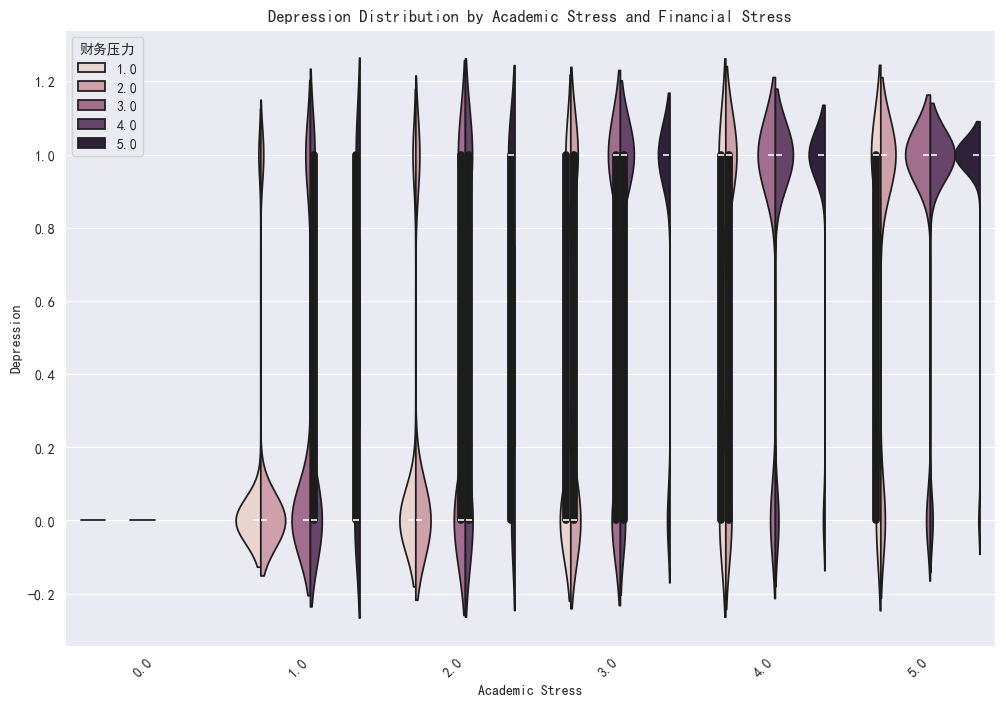

In [27]:
plt.figure(figsize=(12, 8))
sns.violinplot(x='学业压力', y='抑郁症', data=data_cleaned, hue='财务压力', split=True)
plt.title('Depression Distribution by Academic Stress and Financial Stress')
plt.xlabel('Academic Stress')
plt.ylabel('Depression')
plt.xticks(rotation=45)
plt.show()

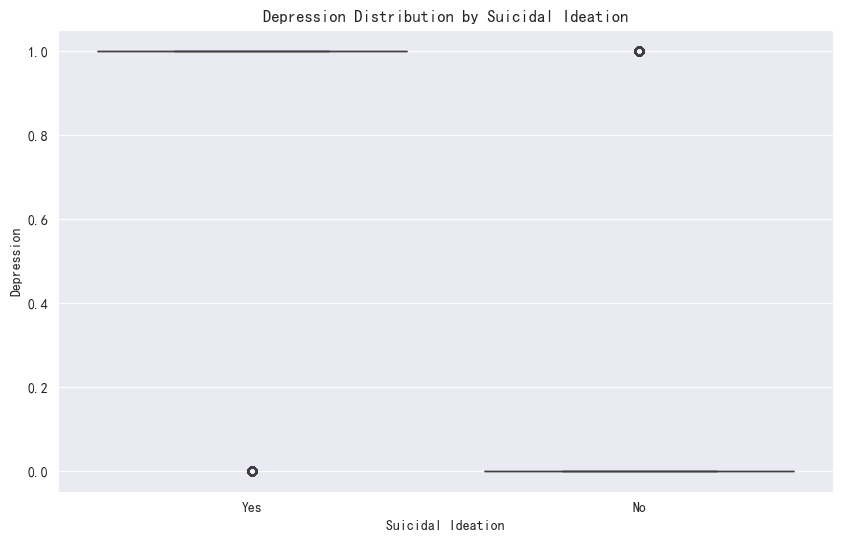

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='是否有过自杀念头', y='抑郁症', data=data_cleaned)
plt.title('Depression Distribution by Suicidal Ideation')
plt.xlabel('Suicidal Ideation')
plt.ylabel('Depression')
plt.show()

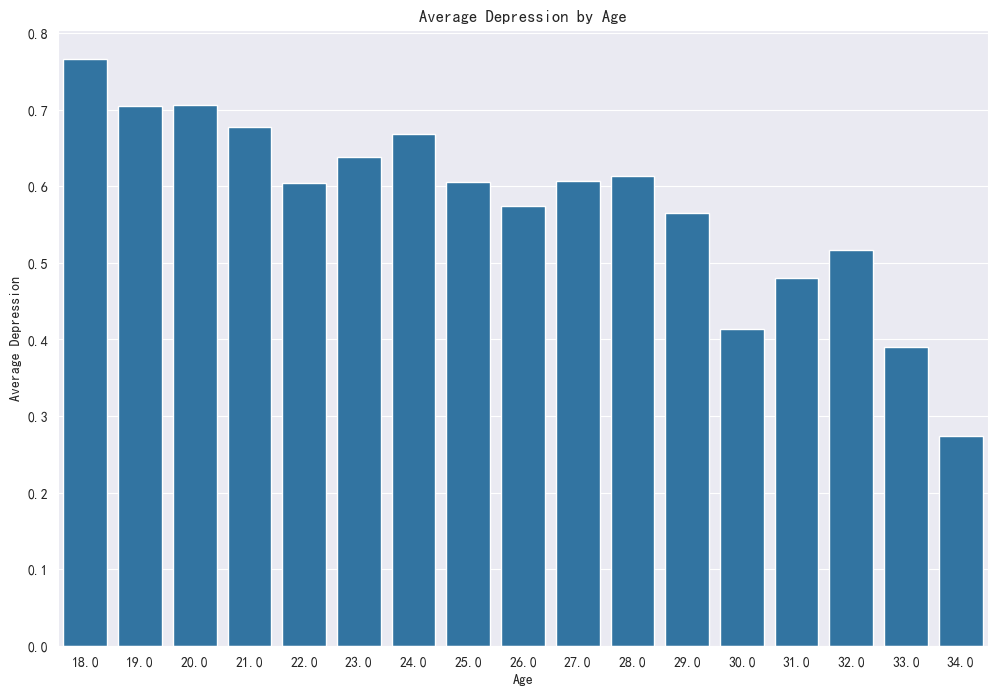

In [29]:
age_depression = data_cleaned.groupby('年龄')['抑郁症'].mean().reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(x='年龄', y='抑郁症', data=age_depression)
plt.title('Average Depression by Age')
plt.xlabel('Age')
plt.ylabel('Average Depression')
plt.show()

In [30]:
# 选择相关特征
selected_features = ['是否有过自杀念头', '学业压力', '财务压力', '抑郁症']
selected_data = data_cleaned[selected_features]

# 计算相关性矩阵
correlation_matrix = selected_data.corr()

# 绘制热力图
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'Yes'